In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Предварительно смотрим на измеренные данные

In [2]:
data = pd.read_csv("data_lev.csv", encoding="1251")
data.head()

,Unnamed: 0,Канал: 0,Канал: 1
0,00:00:00.000.000,-0.2588,-0.2075
1,00:00:00.000.100,-0.2686,-0.2393
2,00:00:00.000.200,-0.2979,-0.2173
3,00:00:00.000.300,-0.3174,-0.1587
4,00:00:00.000.400,-0.3369,-0.1196


In [115]:
data.value_counts()

Unnamed: 0        Канал: 0  Канал: 1  H_relative  i          H_obr        I_rel_0    I_rel    
00:00:00.000.000  -0.2588   -0.2075   -0.351010   -0.883599  -132.539796   0.002364   0.011692    1
00:00:00.000.100  -0.2686   -0.2393   -0.364302   -0.917058  -137.558691  -0.057788  -0.055759    1
00:00:00.000.200  -0.2979   -0.2173   -0.404042   -1.017094  -152.564162  -0.016173  -0.009095    1
00:00:00.000.300  -0.3174   -0.1587   -0.430490   -1.083672  -162.550739   0.094674   0.115201    1
00:00:00.000.400  -0.3369   -0.1196   -0.456937   -1.150249  -172.537315   0.168636   0.198136    1
                                                                                                 ..
00:00:05.247.500   0.0708    0.2783    0.096026    0.241726   36.258955    0.921302   1.042122    1
00:00:05.247.600   0.0903    0.2197    0.122474    0.308304   46.245532    0.810455   0.917825    1
00:00:05.247.700   0.1099    0.1709    0.149057    0.375222   56.283321    0.718145   0.814316    1
00:00

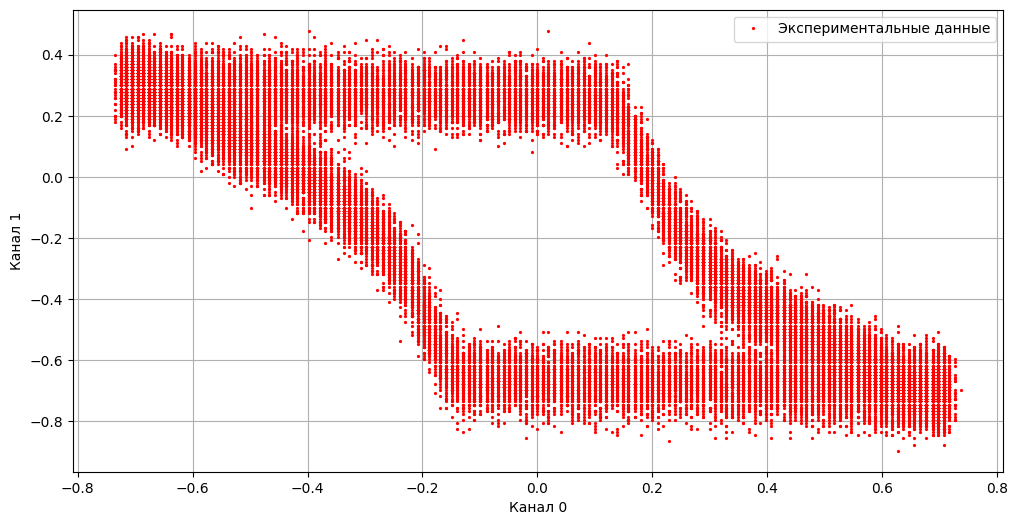

In [19]:
plt.figure(figsize=(12, 6))

plt.grid(True)

plt.xlabel("Канал 0")
plt.ylabel("Канал 1")

plt.errorbar(x=data["Канал: 0"], y=data["Канал: 1"], fmt="or", ms=1.3, label="Экспериментальные данные")

plt.legend()
plt.savefig("pictures/graph_pure.pdf")
plt.show()

По амперметру ток:

$$ i_A = 1.780 ~ А \implies i_\textit{max} = \sqrt{2} i_A = 2.517 ~ А $$

In [5]:
i_A = np.float64('1.780') # А

i_max = np.sqrt(2) * i_A

print(f"i_max = {i_max:.3f} А")

i_max = 2.517 А


Поле от тока:

$$ H(t) = K \cdot i(t) \implies \cfrac{H(t)}{H_\textit{max}} = \cfrac{i(t)}{i_\textit{max}} = \cfrac{U_R (t)}{R i_\textit{max}} = \cfrac{U_\text{K0} (t)}{U_{\text{K0}, \textit{max}}} $$

In [6]:
data["H_relative"] = data["Канал: 0"] / np.max(np.abs(data["Канал: 0"]))
data.head()

,Unnamed: 0,Канал: 0,Канал: 1,H_relative
0,00:00:00.000.000,-0.2588,-0.2075,-0.351010
1,00:00:00.000.100,-0.2686,-0.2393,-0.364302
2,00:00:00.000.200,-0.2979,-0.2173,-0.404042
3,00:00:00.000.300,-0.3174,-0.1587,-0.430490
4,00:00:00.000.400,-0.3369,-0.1196,-0.456937


In [7]:
K = np.float64('150') # эрстед / А

$$ H_\textit{обр} = K \cdot i (t) $$

$$ R = \cfrac{U_{R, \textit{max}}}{i_\textit{max}}$$

In [8]:
R = np.max(data["Канал: 0"]) / i_max
print(f"R = {R:.3f} Ом")

R = 0.293 Ом


In [9]:
data["i"] = data["Канал: 0"] / R
data.head()

,Unnamed: 0,Канал: 0,Канал: 1,H_relative,i
0,00:00:00.000.000,-0.2588,-0.2075,-0.351010,-0.883599
1,00:00:00.000.100,-0.2686,-0.2393,-0.364302,-0.917058
2,00:00:00.000.200,-0.2979,-0.2173,-0.404042,-1.017094
3,00:00:00.000.300,-0.3174,-0.1587,-0.430490,-1.083672
4,00:00:00.000.400,-0.3369,-0.1196,-0.456937,-1.150249


In [10]:
# Эрстед
data["H_obr"] = K * data["i"]
data.head()

,Unnamed: 0,Канал: 0,Канал: 1,H_relative,i,H_obr
0,00:00:00.000.000,-0.2588,-0.2075,-0.351010,-0.883599,-132.539796
1,00:00:00.000.100,-0.2686,-0.2393,-0.364302,-0.917058,-137.558691
2,00:00:00.000.200,-0.2979,-0.2173,-0.404042,-1.017094,-152.564162
3,00:00:00.000.300,-0.3174,-0.1587,-0.430490,-1.083672,-162.550739
4,00:00:00.000.400,-0.3369,-0.1196,-0.456937,-1.150249,-172.537315


$$ I_\textit{отн} = \alpha \cdot \left( \cfrac{U_1 (t) - U_{1, \textit{min}}}{U_{1, \textit{max}} - U_{1, \textit{min}}} \right) + \beta $$


$\alpha$ и $\beta$ -- константы, подобранные для нормировки

In [11]:
alpha_0 = np.float64('2.6')
beta_0 = np.float64('1.3')

In [12]:
data["I_rel_0"] = alpha_0 * (data["Канал: 1"] - np.max(data["Канал: 1"])) / (np.max(data["Канал: 1"]) - np.min(data["Канал: 1"])) + beta_0

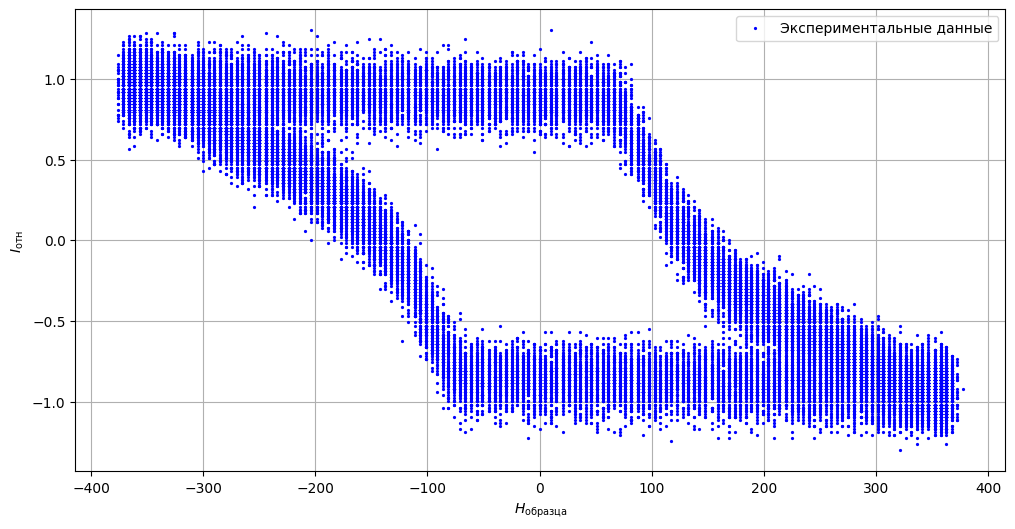

In [21]:
plt.figure(figsize=(12, 6))

plt.grid(True)

plt.xlabel(r"$H_\text{образца}$")
plt.ylabel(r"$I_\text{отн}$")

plt.errorbar(x=data["H_obr"], y=data["I_rel_0"], fmt="ob", ms=1.3, label="Экспериментальные данные")

plt.legend()
plt.savefig("pictures/graph_I_rel_0.pdf")
plt.show()

2.9152724891901016 2.9155053198337555 	 diff = 0.00023283064365386963 	 False


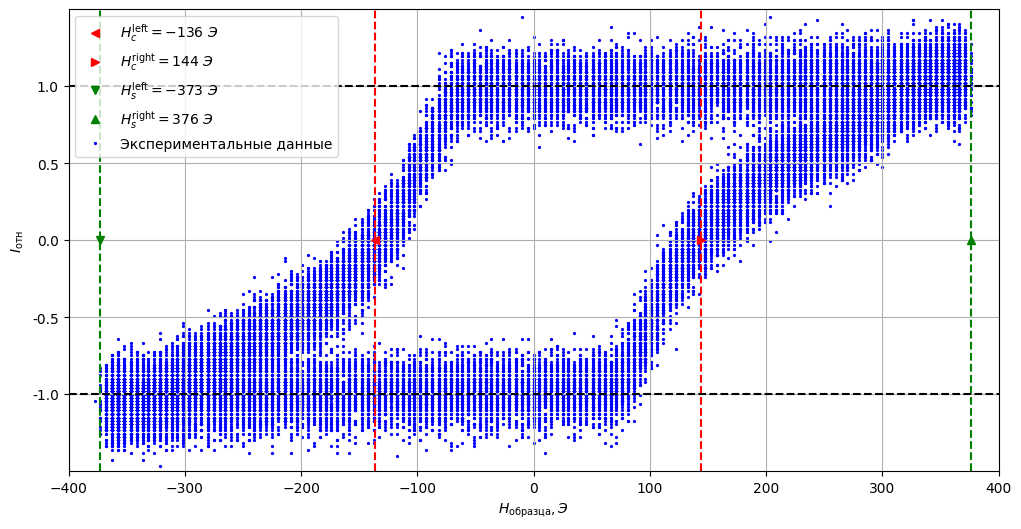

In [104]:
def get_calib_parameters(data, iter_bin_search=50, draw_choose_dots=True):
    ch1 = data["Канал: 1"]
    ch0 = data["Канал: 0"]
    top = []
    bottom = []

    ch1_top = []
    ch0_top = []

    ch1_bottom = []
    ch0_bottom = []

    ch1_extra = []
    ch0_extra = []
    for i in range(len(ch1)):
        if ch1[i] > 0.14 and ch0[i] < 0.17:
            top.append(i)
            ch1_top.append(ch1[i])
            ch0_top.append(ch0[i])
            continue
        
        if ch1[i] < -0.55 and ch0[i] > -0.17:
            bottom.append(i)
            ch1_bottom.append(ch1[i])
            ch0_bottom.append(ch0[i])
            continue

        ch1_extra.append(ch1[i])
        ch0_extra.append(ch0[i])
    
    if draw_choose_dots:
        plt.figure(figsize=(12, 6))
        plt.title("Учитываемые точки при нормировке")

        plt.grid(True)

        plt.xlabel("Канал 0")
        plt.ylabel("Канал 1")

        plt.errorbar(x=ch0_bottom, y=ch1_bottom, fmt="or", ms=1.3, label="Нижние точки")
        plt.errorbar(x=ch0_top, y=ch1_top, fmt="ob", ms=1.3, label="Верхние точки")
        plt.errorbar(x=ch0_extra, y=ch1_extra, fmt="og", ms=1.3, label="Неиспользуемые точки точки")

        plt.legend()
        plt.show()

    
    U_1 = data["Канал: 1"]
    U_1_min=np.min(data["Канал: 1"])
    U_1_max=np.max(data["Канал: 1"])
    x = (U_1 - U_1_min) / (U_1_max - U_1_min)

    a_l, a_r = 0, 1e6
    b = 0

    for _ in range(iter_bin_search):
        a_m = (a_l + a_r) / 2
        y_ = a_m * x
        b = -np.average(y_)

        y = y_ + b
        top_avg = 0
        for i in top:
            top_avg += y[i]
        top_avg /= len(top)


        bottom_avg = 0
        for i in bottom:
            bottom_avg += y[i]
        bottom_avg /= len(bottom)

        metric = ((top_avg - 1) + (-1 - bottom_avg)) / 2

        if metric < 0:
            a_l = a_m
        else:
            a_r = a_m
    
    print(a_l, a_r, f"\t diff = {np.abs(a_l - a_r)} \t", np.abs(a_l - a_r) < 0.0001)
    alpha, beta = a_r, b

    Y = alpha * x + beta
    X = -data["H_obr"]


    H_c_left = 0
    c_left = 0
    H_c_right = 0
    c_right = 0
    for i in range(len(Y)):
        if np.abs(Y[i]) < 0.05:
            if X[i] < 0:
                H_c_left += X[i]
                c_left += 1
            else:
                H_c_right += X[i]
                c_right += 1
    H_c_left /= c_left
    H_c_right /= c_right


    H_s_left = 0
    s_left = 0
    H_s_right = 0
    s_right = 0
    min_X = np.min(X)
    max_X = np.max(X)
    for i in range(len(Y)):
        if X[i] < min_X + 7.5:
            H_s_left += X[i]
            s_left += 1
        
        if X[i] > max_X - 1:
            H_s_right += X[i]
            s_right += 1
    H_s_left /= s_left
    H_s_right /= s_right

    plt.figure(figsize=(12, 6))

    plt.grid(True)

    plt.xlabel(r"$H_\text{образца}, Э$")
    plt.ylabel(r"$I_\text{отн}$")


    plt.plot(H_c_left, 0, "<r", ms=6, zorder=3, label=fr"$H_c^\text{{left}} = {H_c_left:.0f} ~ Э$")
    plt.plot(H_c_right, 0, ">r", ms=6, zorder=3, label=fr"$H_c^\text{{right}} = {H_c_right:.0f} ~ Э$")
    plt.vlines(x=[H_c_left, H_c_right], ymin=-1.5, ymax=1.5, linestyles="--", colors="red")


    plt.plot(H_s_left, 0, "vg", ms=6, zorder=3, label=fr"$H_s^\text{{left}} = {H_s_left:.0f} ~ Э$")
    plt.plot(H_s_right, 0, "^g", ms=6, zorder=3, label=fr"$H_s^\text{{right}} = {H_s_right:.0f} ~ Э$")
    plt.vlines(x=[H_s_left, H_s_right], ymin=-1.5, ymax=1.5, linestyles="--", colors="green")


    plt.errorbar(x=X, y=Y, fmt="ob", ms=1.3, label="Экспериментальные данные", zorder=1)

    plt.hlines(y=1, xmin=-400, xmax=400, linestyles="--", colors="black", zorder=2)
    plt.hlines(y=-1, xmin=-400, xmax=400, linestyles="--", colors="black", zorder=2)

    plt.ylim(-1.5, 1.5)
    plt.xlim(-400, 400)
    plt.yticks(ticks=[-1, -0.5, 0, 0.5, 1],
               labels=["-1.0", "-0.5", "0.0", "0.5", "1.0"])

    plt.legend()
    plt.savefig("pictures/graph_I_rel.pdf")
    plt.show()

    return alpha, beta, H_c_left, H_c_right, H_s_left, H_s_right

alpha, beta, H_c_left, H_c_right, H_s_left, H_s_right = get_calib_parameters(data=data, iter_bin_search=32, draw_choose_dots=False)

In [ ]:
from IPython.display import Markdown, display

In [109]:
Markdown(
    rf"$$I_\textit{{отн}} = {alpha:.3f} \cdot \left( \cfrac{{U_1 (t) - U_{{1, \textit{{min}}}}}}{{U_{{1, \textit{{max}}}} - U_{{1, \textit{{min}}}}}} \right) {beta:.3f}$$"
)

$$I_\textit{отн} = 2.916 \cdot \left( \cfrac{U_1 (t) - U_{1, \textit{min}}}{U_{1, \textit{max}} - U_{1, \textit{min}}} \right) -1.467$$

In [114]:
H_c = (H_c_right - H_c_left) / 2
H_s = (H_s_right - H_s_left) / 2

display(Markdown(f"$H_c = {H_c:.0f}~ Э$"))
display(Markdown(f"$H_s = {H_s:.0f}~ Э$"))

$H_c = 140~ Э$

$H_s = 375~ Э$